# Lab 6 — SHAP Interpretability

**Day 03 · Classification & Model Interpretation · Cisco AI/ML Training**

---

## Goals

1. Compute **SHAP values** to explain individual logistic-regression predictions.
2. Rank features by **mean |SHAP|** across a sample of test rows.
3. Connect SHAP attributions to business intuition (why `int_rate` matters).
4. Visualize global importance with a SHAP bar plot.

> **Quick check:** SHAP shape **(20, 5)** · top driver **`int_rate`** · mean |SHAP| printed




## What is SHAP?

**SHAP** assigns each feature a contribution to a single prediction.

| Concept | Meaning |
|---------|--------|
| **Base value** | Average model output over background |
| **SHAP value** | Feature's push toward higher or lower default probability |
| **Sum** | base + sum(SHAP) ≈ model output for that row |

---

## 1. Load data, split, and train

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]
CATEGORICAL_FEATURES = ["grade", "term"]

import shap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = GH_ROOT / "hands-on" / "03-classification-interpretation" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X = df[NUMERIC_FEATURES]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

print(f"train size: {len(X_train)}, test size: {len(X_test)}")
print("coefficients (scaled features):")
for name, coef in zip(NUMERIC_FEATURES, model.coef_[0]):
    print(f"  {name}: {coef:+.4f}")


C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train size: 800, test size: 200
coefficients (scaled features):
  loan_amnt: -0.0939
  int_rate: +0.4355
  annual_inc: -0.0535
  dti: +0.3325
  installment: -0.1480


---

## 2. Build SHAP explainer

In [2]:
sample = X_test_s[:20]
explainer = shap.Explainer(model, X_train_s, feature_names=NUMERIC_FEATURES)
shap_values = explainer(sample)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"base values (first 3): {shap_values.base_values[:3].round(4)}")


SHAP values shape: (20, 5)
base values (first 3): [-0.0995 -0.0995 -0.0995]


Background = training distribution. We explain **20** scaled test rows.

---

## 3. Global ranking — mean |SHAP|

In [3]:
mean_abs = np.abs(shap_values.values).mean(axis=0)
top_idx = int(np.argmax(mean_abs))
top_feature = NUMERIC_FEATURES[top_idx]

ranking = (
    pd.DataFrame({"feature": NUMERIC_FEATURES, "mean_abs_shap": mean_abs.round(4)})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
display(ranking)
print(f"top driver (mean |SHAP|): {top_feature}")


,feature,mean_abs_shap
0,int_rate,0.3097
1,dti,0.2300
2,installment,0.1180
3,loan_amnt,0.0576
4,annual_inc,0.0545


top driver (mean |SHAP|): int_rate


### Why does `int_rate` often rank first?

Higher interest rates reflect **riskier borrowers**. SHAP shows **per-loan** pushes, not just global coefficients.

### 3b. Compare |coef| vs mean |SHAP|

In [4]:
compare = pd.DataFrame({
    "feature": NUMERIC_FEATURES,
    "abs_coef": np.abs(model.coef_[0]),
    "mean_abs_shap": mean_abs,
}).sort_values("mean_abs_shap", ascending=False)
display(compare.round(4))


,feature,abs_coef,mean_abs_shap
1,int_rate,0.4355,0.3097
3,dti,0.3325,0.2300
4,installment,0.1480,0.1180
0,loan_amnt,0.0939,0.0576
2,annual_inc,0.0535,0.0545


---

## 4. SHAP bar plot

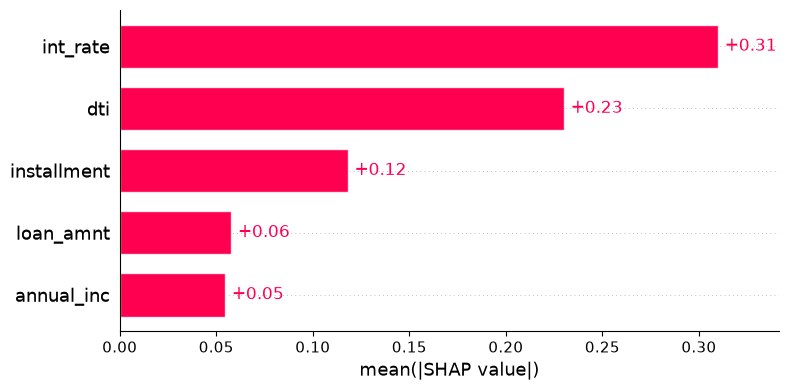

saved: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\03-classification-interpretation\output\shap_bar.png


In [5]:
shap.plots.bar(shap_values, show=False)
bar_plot = OUTPUT_DIR / "shap_bar.png"
plt.tight_layout()
plt.savefig(bar_plot, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved: {bar_plot}")


---

## 5. Waterfall for row 0

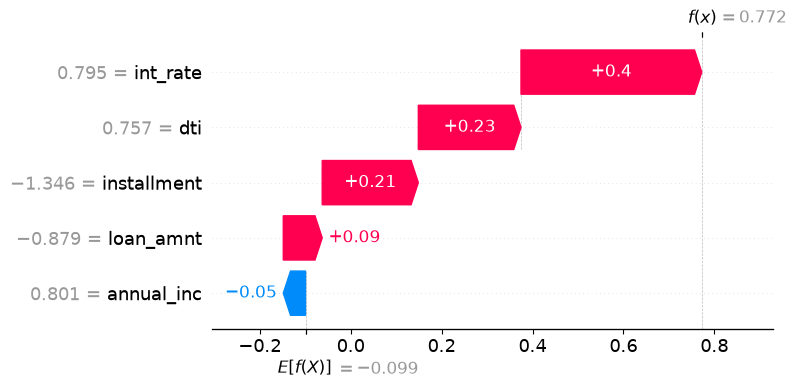

saved: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\03-classification-interpretation\output\shap_waterfall_row0.png
actual default label (row 0): 1
predicted class: 1


In [6]:
shap.plots.waterfall(shap_values[0], show=False)
waterfall_plot = OUTPUT_DIR / "shap_waterfall_row0.png"
plt.tight_layout()
plt.savefig(waterfall_plot, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved: {waterfall_plot}")
print(f"actual default label (row 0): {y_test.iloc[0]}")
print(f"predicted class: {model.predict(sample[:1])[0]}")


### 5b. Force plot intuition (text)

In [7]:
row0_shap = shap_values.values[0]
for feat, val in zip(NUMERIC_FEATURES, row0_shap):
    direction = "↑ default risk" if val > 0 else "↓ default risk"
    print(f"  {feat:12s} SHAP={val:+.4f}  {direction}")


  loan_amnt    SHAP=+0.0857  ↑ default risk
  int_rate     SHAP=+0.3977  ↑ default risk
  annual_inc   SHAP=-0.0489  ↓ default risk
  dti          SHAP=+0.2258  ↑ default risk
  installment  SHAP=+0.2114  ↑ default risk


---

## 6. High-risk row in sample

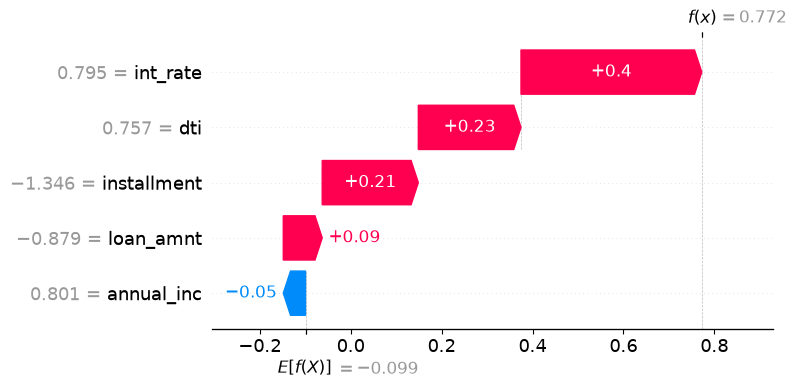

row index 0, P(default)=0.684, actual=1


In [8]:
proba = model.predict_proba(sample)[:, 1]
idx = int(proba.argmax())
shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.show()
print(f"row index {idx}, P(default)={proba[idx]:.3f}, actual={y_test.iloc[idx]}")


### 6b. Low-risk row in sample

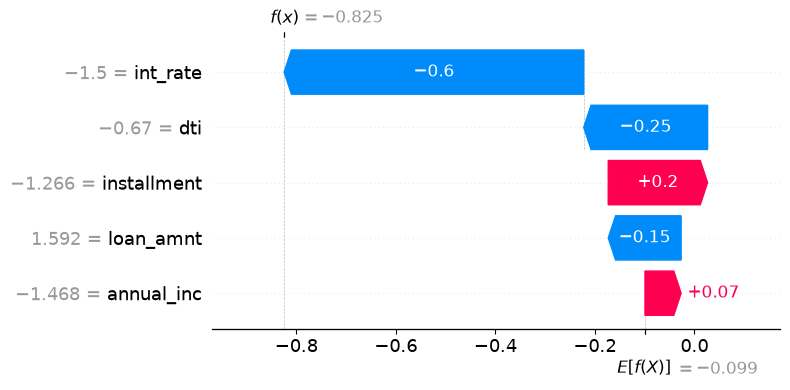

lowest P(default)=0.305, actual=0


In [9]:
idx_low = int(proba.argmin())
shap.plots.waterfall(shap_values[idx_low], show=False)
plt.tight_layout()
plt.show()
print(f"lowest P(default)={proba[idx_low]:.3f}, actual={y_test.iloc[idx_low]}")


### 6c. SHAP values for one feature across 20 rows

In [10]:
int_rate_shap = shap_values.values[:, NUMERIC_FEATURES.index("int_rate")]
print(f"int_rate SHAP — min={int_rate_shap.min():.3f}, max={int_rate_shap.max():.3f}")
print(f"mean={int_rate_shap.mean():.3f}")


int_rate SHAP — min=-0.669, max=0.558
mean=-0.101


### 6d. Base value vs prediction

In [11]:
for i in range(3):
    total = shap_values.base_values[i] + shap_values.values[i].sum()
    print(f"row {i}: base={shap_values.base_values[i]:.3f}, sum SHAP={shap_values.values[i].sum():.3f}")


row 0: base=-0.099, sum SHAP=0.872
row 1: base=-0.099, sum SHAP=-0.495
row 2: base=-0.099, sum SHAP=0.288


### 6e. Explainability for underwriting committee

In [12]:
print("Underwriter question: Why was loan #0 flagged?")
row0 = X_test.iloc[0]
print(row0.to_string())
print(f"\nTop 2 drivers by |SHAP|:")
row0_abs = np.abs(shap_values.values[0])
top2 = np.argsort(row0_abs)[-2:][::-1]
for j in top2:
    print(f"  {NUMERIC_FEATURES[j]}: SHAP={shap_values.values[0,j]:+.4f}")


Underwriter question: Why was loan #0 flagged?
loan_amnt        9132.00
int_rate           18.69
annual_inc     139591.00
dti                26.05
installment       138.17

Top 2 drivers by |SHAP|:
  int_rate: SHAP=+0.3977
  dti: SHAP=+0.2258


### 6f. Pipeline vs plain model SHAP note

In [13]:
print("This lab: SHAP on scaled numeric matrix (fast, clear).")
print("Lab 5 pipeline adds one-hot grade/term — explainer setup is harder.")


This lab: SHAP on scaled numeric matrix (fast, clear).
Lab 5 pipeline adds one-hot grade/term — explainer setup is harder.


### 6g. Mean SHAP sign per feature

In [14]:
mean_signed = shap_values.values.mean(axis=0)
sign_df = pd.DataFrame({"feature": NUMERIC_FEATURES, "mean_shap": mean_signed.round(4)})
display(sign_df)


,feature,mean_shap
0,loan_amnt,0.0003
1,int_rate,-0.1013
2,annual_inc,0.0004
3,dti,0.0739
4,installment,-0.0434


### 6h. Save waterfall file check

In [15]:
print("waterfall saved:", waterfall_plot.is_file())


waterfall saved: True


### 6i. SHAP heatmap-style table (first 5 rows)

In [16]:
shap_table = pd.DataFrame(shap_values.values[:5], columns=NUMERIC_FEATURES)
display(shap_table.round(4))


,loan_amnt,int_rate,annual_inc,dti,installment
0,0.0857,0.3977,-0.0489,0.2258,0.2114
1,-0.0153,-0.3774,-0.0083,0.0745,-0.1685
2,-0.0340,0.5583,-0.0815,-0.0610,-0.0942
3,-0.0459,-0.0491,-0.0846,-0.5440,0.0063
4,-0.1030,0.0932,0.0360,0.0683,-0.1072


### 6j. Feature value at highest SHAP for int_rate

In [17]:
ir_idx = NUMERIC_FEATURES.index("int_rate")
row_max = int(np.argmax(shap_values.values[:, ir_idx]))
print(f"row {row_max}: int_rate raw={X_test.iloc[row_max]['int_rate']}, SHAP={shap_values.values[row_max, ir_idx]:+.4f}")


row 2: int_rate raw=20.72, SHAP=+0.5583


### 6k. Expected value (EV) framing

In [18]:
print("Positive SHAP on int_rate → pushes toward default class.")
print("Negative SHAP on annual_inc → higher income pulls risk down.")


Positive SHAP on int_rate → pushes toward default class.
Negative SHAP on annual_inc → higher income pulls risk down.


### 6l. Re-fit check — same top feature

In [19]:
model2 = LogisticRegression(max_iter=1000, random_state=42)
model2.fit(X_train_s, y_train)
explainer2 = shap.Explainer(model2, X_train_s, feature_names=NUMERIC_FEATURES)
sv2 = explainer2(sample)
ma2 = np.abs(sv2.values).mean(axis=0)
print("top after re-fit:", NUMERIC_FEATURES[int(np.argmax(ma2))])


top after re-fit: int_rate


### 6m. Count rows where int_rate SHAP > 0

In [20]:
print(f"rows with int_rate SHAP>0: {(shap_values.values[:, ir_idx] > 0).sum()} / 20")


rows with int_rate SHAP>0: 8 / 20


### 6n. Link to Lab 2 coefficients

In [21]:
print("int_rate coef (scaled features):", model.coef_[0][ir_idx])
print("positive coef + high int_rate → higher default score")


int_rate coef (scaled features): 0.4355081605576033
positive coef + high int_rate → higher default score


### 6o. SHAP std per feature

In [22]:
shap_std = shap_values.values.std(axis=0)
pd.DataFrame({"feature": NUMERIC_FEATURES, "std_shap": shap_std.round(4)})


,feature,std_shap
0,loan_amnt,0.0727
1,int_rate,0.3513
2,annual_inc,0.0607
3,dti,0.2537
4,installment,0.1265


### 6p. Actual vs predicted on 20-row sample

In [23]:
sample_pred = model.predict(sample)
sample_actual = y_test.iloc[:20].values
print(f"accuracy on 20-row SHAP sample: {(sample_pred == sample_actual).mean():.3f}")


accuracy on 20-row SHAP sample: 0.750


### 6q. Output files list

In [24]:
for p in sorted(OUTPUT_DIR.glob("shap*.png")):
    print(p.name, p.stat().st_size, "bytes")


shap_bar.png 23664 bytes
shap_beeswarm.png 35505 bytes
shap_waterfall_row0.png 34490 bytes


---

## 7. Checkpoint summary

In [25]:
assert shap_values.values.shape == (20, 5)
assert top_feature == "int_rate"
assert mean_abs[top_idx] > mean_abs.mean()
assert bar_plot.is_file()
print("Numbers match — you're good.")



Numbers match — you're good.


## Extension — SHAP beeswarm (global pattern)




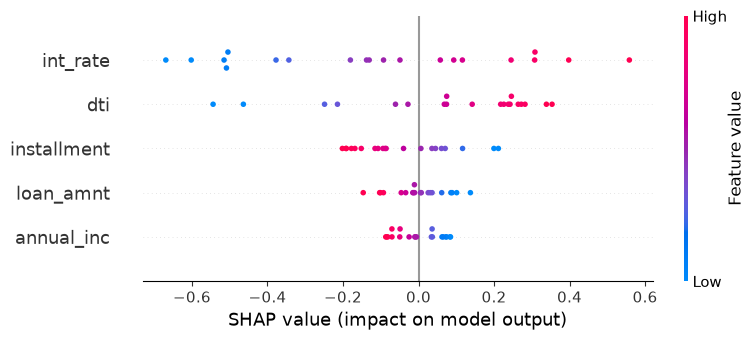

saved: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\03-classification-interpretation\output\shap_beeswarm.png


In [26]:
shap.plots.beeswarm(shap_values, show=False)
beeswarm_plot = OUTPUT_DIR / "shap_beeswarm.png"
plt.tight_layout()
plt.savefig(beeswarm_plot, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved: {beeswarm_plot}")


---

## Reflection questions

1. How is mean |SHAP| different from the absolute value of logistic coefficients?
2. Why pass `X_train_s` as background instead of `X_test_s`?
3. When would SHAP on a **pipeline** (Lab 5) be harder than on a scaled matrix?
4. Does the highest-risk row in the sample match your credit intuition?
